In [1]:
import pandas as pd          # 数据读取、处理、分析的核心库，相当于Excel的Python版
import numpy as np           # 科学计算库，处理数组、数学运算
import matplotlib.pyplot as plt  # 画图库，用来画曲线、柱状图等
from sklearn.model_selection import train_test_split  # 用来把数据随机分成训练集和测试集
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report  # 评估指标
import xgboost as xgb        # XGBoost模型库，是目前最流行的机器学习算法之一
import warnings
warnings.filterwarnings('ignore')  # 忽略一些不影响运行的警告信息，让输出更干净

In [2]:
# 读取CSV文件，文件要放在和这个Notebook相同的文件夹下
# 如果你的文件名不同，请修改下面的 'credit_data_cleaned.csv'
df = pd.read_csv(r"C:\Users\薛人玮\Desktop\credit_data_cleaned.csv")

# .shape 返回 (行数, 列数)
print("数据大小（行，列）:", df.shape)

# .head() 显示前5行，让你看到数据的样子
print("\n前5行数据:")
df.head()

数据大小（行，列）: (150000, 11)

前5行数据:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# 目标列：我们要预测的东西（客户未来两年是否会违约）
# 1表示违约（坏客户），0表示正常（好客户）
target = 'SeriousDlqin2yrs'

# 特征列：用来预测目标的依据。我们选几个最常用、不容易出错的列
# 注意：如果你的数据里这些列名不完全一样，可以改成你实际有的列名
feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines',   # 信用卡使用率（越高风险越大）
    'age',                                    # 年龄
    'DebtRatio',                              # 负债比
    'MonthlyIncome',                          # 月收入
    'NumberOfDependents',                     # 受抚养人数
    'NumberOfTime30-59DaysPastDueNotWorse',   # 借款人历史上出现轻度逾期（超过 30 天但不超过 59 天）的次数
    'NumberOfTimes90DaysLate',                # 借款人经历过最严重的逾期阶段（90 天以上）的次数
    'NumberOfTime60-89DaysPastDueNotWorse',   # 比上一种更严重的逾期，停留在 60–89 天阶段的次数
    'NumberOfOpenCreditLinesAndLoans'         # 借款人当前名下正在使用或可使用的授信账户总数（包括信用卡、分期贷款、房贷等）
]

# 从df中取出特征数据（X）和目标数据（y）
X = df[feature_cols]
y = df[target]

# 检查是否有缺失值（NaN），如果有，简单用该列的中位数填充
# 这一步是为了防止后续模型报错
if X.isnull().any().any():
    print("发现缺失值，用中位数填充...")
    X = X.fillna(X.median())

print("特征数据形状:", X.shape)
print("目标数据形状:", y.shape)

特征数据形状: (150000, 9)
目标数据形状: (150000,)


In [4]:
# train_test_split 作用：把数据随机打乱，然后按比例分成两份
# test_size=0.2 表示20%的数据作为测试集，80%作为训练集
# random_state=42 固定随机种子，这样每次运行拆分结果都一样，方便复现
# stratify=y 让训练集和测试集中好/坏客户的比例和原始数据保持一致（重要！）

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"训练集大小: {X_train.shape[0]} 条")
print(f"测试集大小: {X_test.shape[0]} 条")
print(f"训练集中坏客户比例: {y_train.mean():.2%}")
print(f"测试集中坏客户比例: {y_test.mean():.2%}")

训练集大小: 120000 条
测试集大小: 30000 条
训练集中坏客户比例: 6.68%
测试集中坏客户比例: 6.68%


In [5]:
# 在信贷数据中，坏客户通常很少（比如只有5%）。模型会倾向于把所有客户都猜成好客户。
# 我们需要给坏客户更高的权重，让模型重视它们。
# 计算权重比例scale_pos_weight：好客户数量 / 坏客户数量
# 这个ratio会在训练模型时传给 scale_pos_weight 参数

ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"样本不均衡权重比例: {ratio:.2f}%")

样本不均衡权重比例: 13.96%


In [6]:
# 创建XGBoost分类器对象（Classifier表示做分类任务）
model = xgb.XGBClassifier(
    n_estimators=100,          # 决策树的数量（越多越慢，但通常效果越好）
    max_depth=4,               # 每棵树的深度（太深容易过拟合，4~6常见）
    learning_rate=0.1,         # 学习率（每一步更新的步长，越小越需要更多树）
    scale_pos_weight=ratio,    # 正负样本权重比例（样本不均衡权重比例，处理不均衡）
    random_state=42,           # 固定随机种子
    use_label_encoder=False,   # 避免一个版本警告（不用管）
    eval_metric='logloss'      # 评估指标：对数损失（分类问题常用）
)

# 训练模型：用训练集去拟合
# 模型会学习特征 X_train 和 目标 y_train 之间的关系
model.fit(X_train, y_train)

print("模型训练完成！")

模型训练完成！


In [7]:
# predict_proba 返回每个样本属于每个类别的概率
# 返回格式：[[P(好客户), P(坏客户)], ...]
# 我们取第二列 [:, 1] 即坏客户的概率

y_pred_prob = model.predict_proba(X_test)[:, 1]

# 计算AUC值（Area Under Curve，曲线下面积）
# AUC越接近1，模型区分好坏客户的能力越强；0.5等于瞎猜

auc = roc_auc_score(y_test, y_pred_prob)
print(f"测试集AUC: {auc:.4f}")

# 解释：一般来说，AUC > 0.7 就算可用，> 0.8 就算很好

测试集AUC: 0.8688


In [8]:
# KS值衡量模型能把好坏客户分开的程度，范围0~1，越大越好
# 下面是一个自定义函数，用到了 roc_curve 库函数
from sklearn.metrics import roc_curve

def calculate_ks(y_true, y_pred_prob):
    # roc_curve 返回三个值：假正率(FPR)、真正率(TPR)、阈值
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    
    # KS = max(TPR - FPR)
    ks = max(tpr - fpr)
    
    return ks

ks = calculate_ks(y_test, y_pred_prob)
print(f"测试集KS值: {ks:.4f}")

# 解释：KS > 0.3 可用，> 0.4 良好

测试集KS值: 0.5739


In [9]:
# 为了得到分类报告，我们需要把概率转换成0/1预测
# 通常以0.5为阈值：概率 >=0.5 预测为坏客户(1)，否则为好客户(0)

"""
    y_pred_prob: 模型预测样本为正类（坏客户）的概率，取值在 0 到 1 之间
    y_pred_prob >= 0.5: 将每个概率值与 0.5 进行比较，生成一个布尔数组：概率 ≥ 0.5 为 True，否则为 False
    .astype(int): 将布尔值转换为整数：True → 1，False → 0
    y_pred_class: 最终得到的类别标签数组，仅包含 0 和 1

"""
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# 混淆矩阵：[[TN, FP], [FN, TP]]
# TN: 好客户猜对的数量，FP: 好客户猜错的数量
# FN: 坏客户猜错的数量，TP: 坏客户猜对的数量
"""
    TN — True Negative
    真阴性：预测为好客户，实际也是好客户。

    FP — False Positive
    假阳性（第一类错误）：预测为坏客户，实际却是好客户。

    FN — False Negative
    假阴性（第二类错误）：预测为好客户，实际却是坏客户。

    TP — True Positive
    真阳性：预测为坏客户，实际也是坏客户。
"""

cm = confusion_matrix(y_test, y_pred_class)
print("混淆矩阵:")
print(cm)

# 分类报告：包含精确率、召回率、F1分数
print("\n分类报告:")
print(classification_report(y_test, y_pred_class, target_names=['好客户', '坏客户']))

混淆矩阵:
[[22264  5731]
 [  451  1554]]

分类报告:
              precision    recall  f1-score   support

         好客户       0.98      0.80      0.88     27995
         坏客户       0.21      0.78      0.33      2005

    accuracy                           0.79     30000
   macro avg       0.60      0.79      0.61     30000
weighted avg       0.93      0.79      0.84     30000



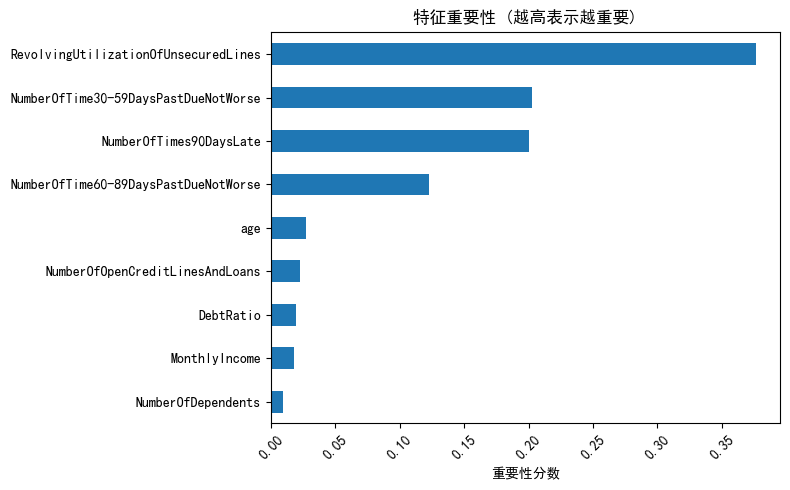

In [10]:
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# XGBoost模型可以输出每个特征的重要性（这个特征对预测的贡献有多大）
importance = model.feature_importances_

# 把特征名和重要性拼在一起，降序排序
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=False)

# 画柱状图
plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh')     # 水平条形图
plt.title('特征重要性 (越高表示越重要)')
plt.xlabel('重要性分数')
plt.gca().invert_yaxis()       # 让最重要的特征排在最上面
plt.xticks(rotation=45)        # 将 x 轴上的刻度标签旋转 45 度
plt.tight_layout()             # 自动调整图形布局
plt.show()

# 观察：哪个特征最重要？通常“信用卡使用率”会排第一

In [11]:
# 把训练好的模型保存成文件，以后可以直接加载使用，不用重新训练
model.save_model('day06_credit_model.ubj')
print("模型已保存为 day06_credit_model.ubj")

# 加载模型的示例（注释掉，以后用）
# loaded_model = xgb.XGBClassifier()
# loaded_model.load_model('my_first_credit_model.ubj')

模型已保存为 day06_credit_model.ubj


In [12]:
print("\n========== 项目总结 ==========")
print(f"数据集大小: {len(df)} 条")
print(f"特征数量: {len(feature_cols)}")
print(f"测试集AUC: {auc:.4f}")
print(f"测试集KS:  {ks:.4f}")
print("模型已训练并保存。你可以用这些指标去面试时展示。")


========== 项目总结 ==========
数据集大小: 150000 条
特征数量: 9
测试集AUC: 0.8688
测试集KS:  0.5739
模型已训练并保存。你可以用这些指标去面试时展示。


In [13]:
# ==================== 附加 - SHAP ====================

In [14]:
# ==================== SHAP 分析（使用 XGBoost 内置方法） ====================
# 注意：必须通过 booster 对象调用，而不是直接调用 XGBClassifier

# 选取一小部分测试样本（100个），方便快速计算
X_sample = X_test.sample(n=100, random_state=42)

# 1. 从训练好的分类器中获取底层的 Booster 对象
booster = model.get_booster()

# 2. 将样本转换为 XGBoost 的高效数据格式 DMatrix
dmatrix_sample = xgb.DMatrix(X_sample)

# 3. 使用 booster 预测，返回 SHAP 贡献值（包含特征贡献 + 基线值）
# 返回形状: (样本数, 特征数+1)，最后一列是基线值（base score）
shap_values_with_base = booster.predict(dmatrix_sample, pred_contribs=True)

# 4. 分离特征贡献部分（去掉最后一列）
shap_values = shap_values_with_base[:, :-1]   # shape: (100, 特征数)
base_value = shap_values_with_base[0, -1]     # 基线值（所有样本相同）

print(f"基线值 (平均对数几率): {base_value:.4f}")
print(f"SHAP 值矩阵形状: {shap_values.shape}")

基线值 (平均对数几率): 0.0018
SHAP 值矩阵形状: (100, 9)


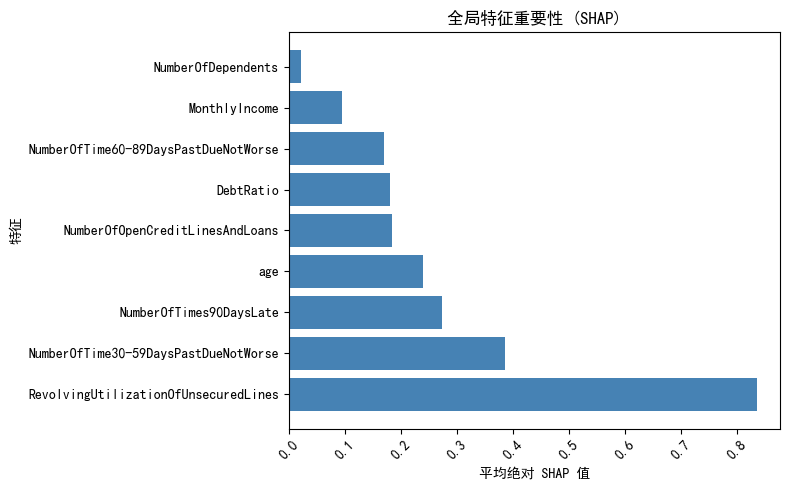

特征重要性排序:
                                feature  mean_abs_shap
0  RevolvingUtilizationOfUnsecuredLines       0.835424
5  NumberOfTime30-59DaysPastDueNotWorse       0.385950
6               NumberOfTimes90DaysLate       0.273588
1                                   age       0.239875
8       NumberOfOpenCreditLinesAndLoans       0.184642
2                             DebtRatio       0.181847
7  NumberOfTime60-89DaysPastDueNotWorse       0.170698
3                         MonthlyIncome       0.094427
4                    NumberOfDependents       0.022262


In [15]:
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ------------------- 1. 全局特征重要性（基于 SHAP 平均绝对值） -------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_df['feature'], importance_df['mean_abs_shap'], color='steelblue')
plt.xlabel('平均绝对 SHAP 值')
plt.ylabel('特征')
plt.title('全局特征重要性 (SHAP)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("特征重要性排序:")
print(importance_df)

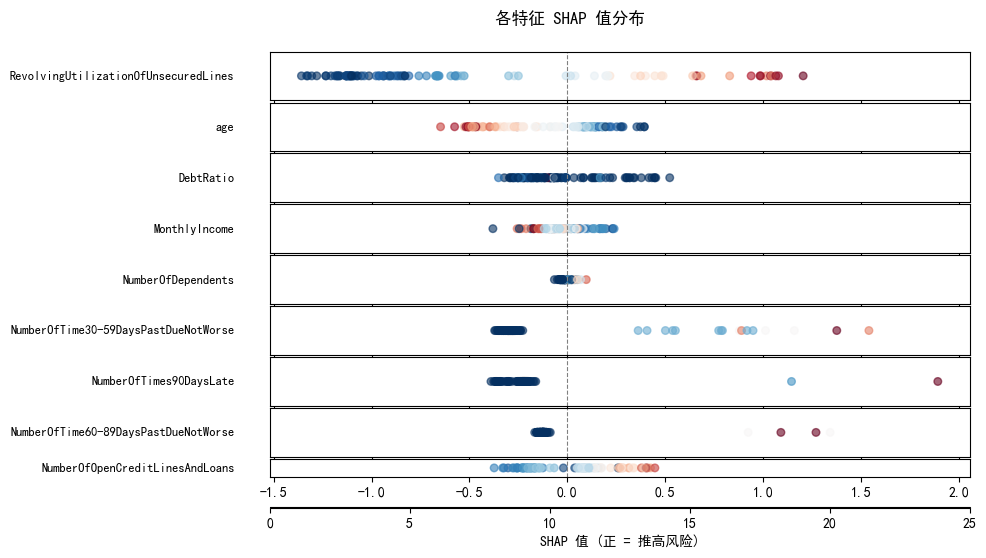

In [16]:
# ------------------- 2. 各特征 SHAP 值分布图（影响方向与特征值的关系） -------------------
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

n_features = len(feature_cols)
fig, axes = plt.subplots(nrows=n_features, figsize=(10, max(6, n_features*0.5)), sharex=True)  # 高度动态调整
fig.subplots_adjust(left=0.2, bottom=0.12, hspace=0.05)   # hspace 缩小，bottom 留空间给 x 轴标签

for i, feature in enumerate(feature_cols):
    ax = axes[i]
    shap_vals = shap_values[:, i]
    feature_vals = X_sample[feature].values
    norm = plt.Normalize(vmin=feature_vals.min(), vmax=feature_vals.max())
    colors = plt.cm.RdBu_r(norm(feature_vals))
    ax.scatter(shap_vals, np.zeros_like(shap_vals), c=colors, alpha=0.6, s=30)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_yticks([])
    ax.text(-0.05, 0.5, feature, transform=ax.transAxes,
            ha='right', va='center', fontsize=9)

# 在最后一个子图下方创建 colorbar
last_ax = axes[-1]
divider = make_axes_locatable(last_ax)
cax = divider.append_axes('bottom', size='5%', pad=0.3)   # pad 控制 colorbar 与子图的间距
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('特征值 (低 → 高)')

plt.xlabel('SHAP 值 (正 = 推高风险)')
plt.suptitle('各特征 SHAP 值分布', y=0.95)   # 标题下移
plt.show()

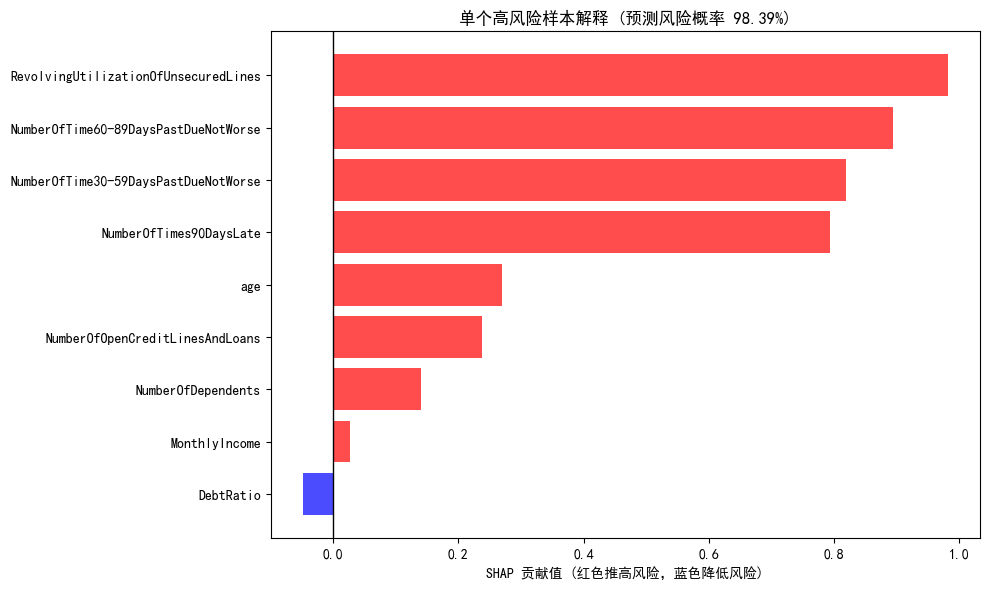

基线值: 0.0018
各特征贡献总和: 4.1136
最终对数几率: 4.1154 -> 概率 98.39%


In [17]:
# ------------------- 3. 单个高风险样本解释（条形图，类似瀑布图） -------------------
# 找出测试集中预测概率最高的样本
probs = model.predict_proba(X_test)[:, 1]
high_risk_idx = probs.argmax()
X_individual = X_test.iloc[[high_risk_idx]]

# 计算该样本的 SHAP 值（同样用 booster）
dmatrix_ind = xgb.DMatrix(X_individual)
shap_ind_with_base = booster.predict(dmatrix_ind, pred_contribs=True)
shap_ind = shap_ind_with_base[0, :-1]
base_ind = shap_ind_with_base[0, -1]

# 绘制水平条形图
contrib_pairs = sorted(zip(feature_cols, shap_ind), key=lambda x: x[1], reverse=False)
features_sorted = [p[0] for p in contrib_pairs]
values_sorted = [p[1] for p in contrib_pairs]

plt.figure(figsize=(10, 6))
colors = ['red' if v > 0 else 'blue' for v in values_sorted]
plt.barh(features_sorted, values_sorted, color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('SHAP 贡献值 (红色推高风险，蓝色降低风险)')
plt.title(f'单个高风险样本解释 (预测风险概率 {probs[high_risk_idx]:.2%})')
plt.tight_layout()
plt.show()

# 输出具体数值供参考
print(f"基线值: {base_ind:.4f}")
print(f"各特征贡献总和: {shap_ind.sum():.4f}")
print(f"最终对数几率: {base_ind + shap_ind.sum():.4f} -> 概率 {probs[high_risk_idx]:.2%}")

In [19]:
# ------------------- 4. 预测概率AUC、KS值、混淆矩阵（阈值0.5） -------------------
# 预测概率
y_pred_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc:.4f}")

# KS值
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ks = max(tpr - fpr)
print(f"KS: {ks:.4f}")

# 混淆矩阵（阈值0.5）
y_pred_class = (y_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_class)
print("混淆矩阵:")
print(cm)

AUC: 0.8688
KS: 0.5739
混淆矩阵:
[[22264  5731]
 [  451  1554]]
